In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


## 1. Imports and paths

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.utils.class_weight import compute_class_weight

In [ ]:
ROOT = "/content/drive/My Drive/Eye Disease/Dataset"

CSV_PATH = os.path.join(ROOT, "full_df.csv")

TRAIN_DIR = os.path.join(ROOT, "ODIR-5K", "ODIR-5K" ,"Training Images")

TEST_DIR = os.path.join(ROOT, "ODIR-5K","ODIR-5K", "Testing Images")

PREPROCESS_DIR = os.path.join(ROOT, "preprocessed_images")

## 2. Load the split CSV files


In [ ]:
train_df = pd.read_csv(os.path.join(ROOT, "train.csv"))
val_df   = pd.read_csv(os.path.join(ROOT, "validation.csv"))
test_df  = pd.read_csv(os.path.join(ROOT, "test.csv"))

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (4474, 21)
Validation: (959, 21)
Test: (959, 21)


Check the label distribution:

In [ ]:
print("Training distribution:")
print(train_df["label"].value_counts())

print("\nValidation distribution:")
print(val_df["label"].value_counts())

print("\nTesting distribution:")
print(test_df["label"].value_counts())

Training distribution:
label
D    1486
N    1470
O     626
G     239
C     225
A     187
M     180
H      61
Name: count, dtype: int64

Validation distribution:
label
D    319
N    316
O    134
G     51
C     48
A     40
M     38
H     13
Name: count, dtype: int64

Testing distribution:
label
D    318
N    315
O    134
G     51
C     49
A     40
M     39
H     13
Name: count, dtype: int64


## 3. Create label encoding


In [ ]:
class_names = sorted(train_df["label"].unique())

class_to_idx = {
    class_name: idx
    for idx, class_name in enumerate(class_names)
}

idx_to_class = {
    idx: class_name
    for class_name, idx in class_to_idx.items()
}

print("Class mapping:")
print(class_to_idx)

Class mapping:
{'A': 0, 'C': 1, 'D': 2, 'G': 3, 'H': 4, 'M': 5, 'N': 6, 'O': 7}


Then apply it to all three datasets:

In [ ]:
train_df["label_idx"] = train_df["label"].map(class_to_idx)
val_df["label_idx"]   = val_df["label"].map(class_to_idx)
test_df["label_idx"]  = test_df["label"].map(class_to_idx)

Verify:

In [ ]:
print(train_df[["label", "label_idx"]].drop_duplicates())

   label  label_idx
0      N          6
1      M          5
2      O          7
5      A          0
7      C          1
8      D          2
47     G          3
84     H          4


## 4. Calculate class weights


In [ ]:
classes = np.array(sorted(train_df["label_idx"].unique()))

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label_idx"]
)

print("Class weights:")
for class_idx, weight in zip(classes, class_weights):
    print(f"{idx_to_class[class_idx]}: {weight:.4f}")

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
)

print(class_weights)



Class weights:
A: 2.9906
C: 2.4856
D: 0.3763
G: 2.3400
H: 9.1680
M: 3.1069
N: 0.3804
O: 0.8934
tensor([2.9906, 2.4856, 0.3763, 2.3400, 9.1680, 3.1069, 0.3804, 0.8934])


## 5. Define image transformations


In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(
        degrees=10
    ),

    transforms.RandomResizedCrop(
        size=224,
        scale=(0.9, 1.0)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

Validation and testing transformations

In [ ]:
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

## 6. Define the custom PyTorch Dataset


In [ ]:
class ODIRDataset(Dataset):

    def __init__(
        self,
        dataframe,
        image_dir,
        transform=None
    ):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        image_name = row["filename"]
        label = row["label_idx"]

        image_path = os.path.join(
            self.image_dir,
            image_name
        )

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(
            label,
            dtype=torch.long
        )

        return image, label

## 7. Set the image directory


In [ ]:
IMAGE_DIR = os.path.join(
    ROOT,
    "preprocessed_images"
)

print("Image directory:", IMAGE_DIR)
print("Number of files:", len(os.listdir(IMAGE_DIR)))

Image directory: /content/drive/My Drive/Eye Disease/Dataset/preprocessed_images
Number of files: 6392


## 8. Create the datasets

In [ ]:
train_dataset = ODIRDataset(
    dataframe=train_df,
    image_dir=IMAGE_DIR,
    transform=train_transform
)

val_dataset = ODIRDataset(
    dataframe=val_df,
    image_dir=IMAGE_DIR,
    transform=val_test_transform
)

test_dataset = ODIRDataset(
    dataframe=test_df,
    image_dir=IMAGE_DIR,
    transform=val_test_transform
)

Check the dataset sizes:

In [ ]:
print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

Train dataset: 4474
Validation dataset: 959
Test dataset: 959


## 9. Verify that the dataset works

Before creating DataLoaders, test one image:

In [ ]:
image, label = train_dataset[0]

print("Image shape:", image.shape)
print("Label index:", label)
print("Label name:", idx_to_class[label.item()])

Image shape: torch.Size([3, 224, 224])
Label index: tensor(6)
Label name: N


## 10. Visualize augmented images

In [ ]:
def show_augmented_images(dataset, num_images=6):

    plt.figure(figsize=(15, 8))

    for i in range(num_images):

        image, label = dataset[i]

        image = image.permute(1, 2, 0).numpy()

        # Undo normalization for visualization
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])

        image = image * std + mean
        image = np.clip(image, 0, 1)

        plt.subplot(2, 3, i + 1)
        plt.imshow(image)
        plt.title(idx_to_class[label.item()])
        plt.axis("off")

    plt.tight_layout()
    plt.show()



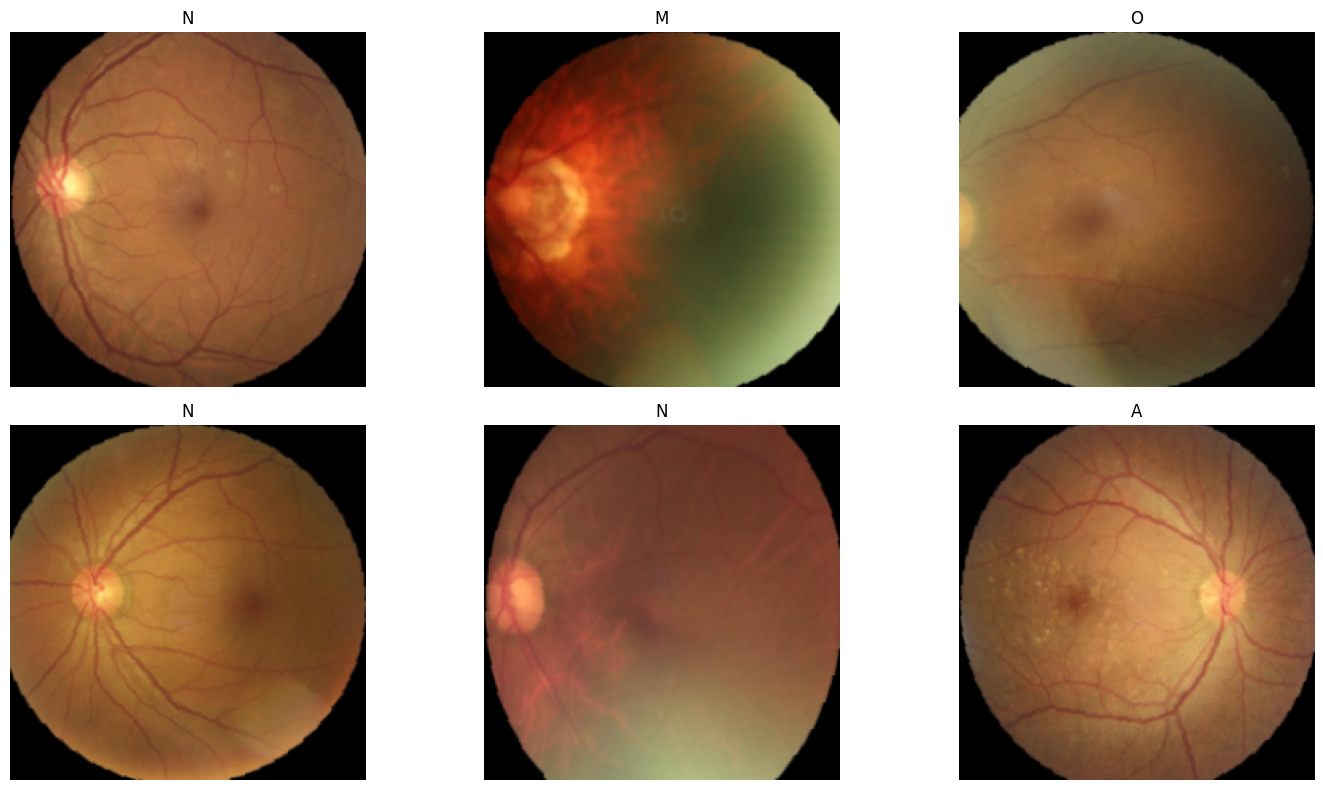

In [ ]:
show_augmented_images(train_dataset)

## 11. Create DataLoaders

In [ ]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

## 12. Final batch verification

In [ ]:
images, labels = next(iter(train_loader))

print("Batch image shape:", images.shape)
print("Batch labels shape:", labels.shape)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Batch image shape: torch.Size([32, 3, 224, 224])
Batch labels shape: torch.Size([32])
